In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# parameters
N_RUNS = 1000
N_REPS = 5000
BASE_SEED = 1000

N_B_PRIMERS_LIST = [2, 3, 4]
N_B_COMPONENTS_LIST = [2, 3, 4]

WITHIN_B_RATIO_CHOICES = [1, 5, 10, 50, 100, 200, 400, 800, 1600, 5000]

A_TRUE = 100
B_BASE_COMPONENT = 100

LOG_BASES = range(2, 11)
EPS = 1e-12

In [3]:
# Helper
def _as_1d_array(x, length=None, dtype=float, name="value"):
    arr = np.asarray(x, dtype=dtype)
    if arr.ndim == 0:
        if length is None:
            return arr.reshape(1)
        return np.full(length, arr.item(), dtype=dtype)
    arr = arr.reshape(-1)
    if length is not None and arr.size != length:
        raise ValueError(f"{name} must have length {length}, got {arr.size}")
    return arr


def make_B_components_within_B(
    n_B_components,
    ratio_choices=None,
    base_component=100,
    rng=None,
    replace=True,
):
    if n_B_components < 1:
        raise ValueError("n_B_components must be >= 1")

    if ratio_choices is None:
        ratio_choices = WITHIN_B_RATIO_CHOICES

    ratio_choices = np.asarray(ratio_choices, dtype=int)

    if rng is None:
        rng = np.random.default_rng()

    chosen_component_ratios = rng.choice(
        ratio_choices,
        size=n_B_components,
        replace=replace,
    )
    B_true_components = tuple((base_component * chosen_component_ratios).astype(int).tolist())

    return B_true_components, tuple(chosen_component_ratios.tolist())


def random_preference_matrix(n_B_primers, n_B_components, rng):
    pref = np.zeros((n_B_primers, n_B_components), dtype=float)

    for j in range(n_B_primers):
        n_pref = int(rng.integers(1, min(2, n_B_components) + 1))
        chosen = rng.choice(n_B_components, size=n_pref, replace=False)
        pref[j, chosen] = 1.0

    return pref

In [4]:
#parameter generator
def random_example_params_fixed_shape(
    n_B_primers,
    n_B_components,
    seed=None,
    A_true=100,
    B_base_component=100,
):
    rng = np.random.default_rng(seed)

    B_true_components, chosen_component_ratios = make_B_components_within_B(
        n_B_components=n_B_components,
        ratio_choices=WITHIN_B_RATIO_CHOICES,
        base_component=B_base_component,
        rng=rng,
        replace=True,
    )

    params = {
        "n_B_primers": int(n_B_primers),
        "n_B_components": int(n_B_components),
        "A_true": int(A_true),
        "B_true_components": tuple(B_true_components),
        "chosen_component_ratios": tuple(chosen_component_ratios),
        "pA": float(rng.uniform(0.5, 1.0)),
        "p_B": tuple(rng.uniform(0.5, 1.0, size=n_B_primers)),
        "gA": float(rng.uniform(1.7, 2.0)),
        "g_B": tuple(rng.uniform(1.7, 2.0, size=n_B_primers)),
        "cA": int(rng.integers(3, 17)),
        "c_B": tuple(rng.integers(3, 17, size=n_B_primers)),
        "complementary_prob": float(rng.uniform(0.0, 1.0)),
        "cross_scale": float(rng.uniform(0.02, 0.40)),
        "weak_dropout_prob": float(rng.uniform(0.0, 0.6)),
        "weak_dropout_scale": float(rng.uniform(0.02, 0.5)),
        "measurement_cv": float(rng.uniform(0.0, 0.3)),
        "preferred_matrix": random_preference_matrix(
            n_B_primers=n_B_primers,
            n_B_components=n_B_components,
            rng=rng,
        ),
    }
    return params

In [5]:
# evaluated approach
def aggregate_B_logbin_multi(B_obs_by_primer, base=6, eps=1e-12):

    B = np.maximum(np.asarray(B_obs_by_primer, dtype=float), eps)
    if B.ndim != 2:
        raise ValueError("B_obs_by_primer must be 2D")

    n_reps = B.shape[0]
    out = np.zeros(n_reps, dtype=float)

    logB = np.floor(np.log(B) / np.log(base)).astype(int)

    for i in range(n_reps):
        bins = logB[i]
        vals = B[i]

        total = 0.0
        for b in np.unique(bins):
            total += vals[bins == b].mean()

        out[i] = total

    return out


def inverse_variance_mean_multi(B_obs_by_primer, p_B, measurement_cv,
                                disagreement_weight=1.0, eps=1e-12):
    B = np.maximum(np.asarray(B_obs_by_primer, dtype=float), eps)
    p_B = _as_1d_array(p_B, length=B.shape[1], dtype=float, name="p_B")

    base_var = B * (1 - p_B[None, :]) / np.maximum(p_B[None, :], eps)
    base_var = base_var + (measurement_cv ** 2) * (B ** 2 + base_var)

    logB = np.log(B)
    med_logB = np.median(logB, axis=1, keepdims=True)
    disagreement = (logB - med_logB) ** 2

    var = base_var + disagreement_weight * disagreement
    w = 1.0 / np.maximum(var, eps)

    return np.sum(w * B, axis=1) / np.maximum(np.sum(w, axis=1), eps)


def geometric_mean_multi(B_obs_by_primer, eps=1e-12):
    B = np.maximum(np.asarray(B_obs_by_primer, dtype=float), eps)
    return np.exp(np.mean(np.log(B), axis=1))


def harmonic_mean_multi(B_obs_by_primer, eps=1e-12):
    B = np.maximum(np.asarray(B_obs_by_primer, dtype=float), eps)
    return B.shape[1] / np.sum(1.0 / B, axis=1)


def build_B_aggregation_methods(B_obs_by_primer, p_B, measurement_cv, bases=range(2, 11), eps=1e-12):
    method_to_B_est = {
        "mean_all": np.mean(B_obs_by_primer, axis=1),
        "max_all": np.max(B_obs_by_primer, axis=1),
        "sum_all": np.sum(B_obs_by_primer, axis=1),
        "geometric_mean_all": geometric_mean_multi(B_obs_by_primer, eps=eps),
        "harmonic_mean_all": harmonic_mean_multi(B_obs_by_primer, eps=eps),
        "inverse_variance_mean_all": inverse_variance_mean_multi(
            B_obs_by_primer, p_B=p_B, measurement_cv=measurement_cv, eps=eps
        ),
    }

    for base in bases:
        method_to_B_est[f"cluster_log{base}_meansame_sumdiff"] = aggregate_B_logbin_multi(
            B_obs_by_primer,
            base=base,
            eps=eps,
        )

    return method_to_B_est

In [6]:
#  B only: compared B_est vs B_true
def summarize_B_metrics(B_est_agg, B_true_total, method, eps=1e-12):
    rel_err = (B_est_agg - B_true_total) / np.maximum(B_true_total, eps)

    return {
        "method": method,
        "MAPE": float(np.mean(np.abs(rel_err))),
        "median_MAPE": float(np.median(np.abs(rel_err))),
        "relative_bias": float(np.mean(rel_err)),
        "median_relative_bias": float(np.median(rel_err)),
    }

In [7]:
# simulation
def simulate_multiB_primers_mixture(
    A_true=100,
    B_true_components=(10, 10000),
    pA=0.8,
    p_B=(0.7, 0.8),
    gA=1.9,
    g_B=(1.7, 2.0),
    cA=16,
    c_B=(3, 16),
    complementary_prob=0.5,
    cross_scale=0.7,
    weak_dropout_prob=0.10,
    weak_dropout_scale=0.50,
    preferred_matrix=None,
    n_reps=5000,
    measurement_cv=0.10,
    seed=2026,
):
    rng = np.random.default_rng(seed)

    B_true_components = _as_1d_array(B_true_components, dtype=float, name="B_true_components")
    B_true_components_int = np.rint(B_true_components).astype(int)
    n_B_components = B_true_components_int.size

    p_B = _as_1d_array(p_B, dtype=float, name="p_B")
    n_B_primers = p_B.size
    g_B = _as_1d_array(g_B, length=n_B_primers, dtype=float, name="g_B")
    c_B = _as_1d_array(c_B, length=n_B_primers, dtype=int, name="c_B")

    if preferred_matrix is None:
        preferred = random_preference_matrix(n_B_primers, n_B_components, rng)
    else:
        preferred = np.asarray(preferred_matrix, dtype=float)
        if preferred.shape != (n_B_primers, n_B_components):
            raise ValueError(
                f"preferred_matrix must have shape {(n_B_primers, n_B_components)}, got {preferred.shape}"
            )
        preferred = (preferred > 0).astype(float)

    if np.any(preferred.sum(axis=1) == 0):
        raise ValueError("Each B primer must prefer at least one component.")

    B_true_total = float(B_true_components_int.sum())

    complementary_mode = rng.random(n_reps) < complementary_prob
    weights = np.ones((n_reps, n_B_primers, n_B_components), dtype=float)
    comp_weights = np.where(preferred[None, :, :] > 0, 1.0, cross_scale)

    off_target_mask = preferred[None, :, :] == 0
    dropout_events = (
        rng.random((n_reps, n_B_primers, n_B_components)) < weak_dropout_prob
    )
    dropout_factor = np.where(dropout_events, weak_dropout_scale, 1.0)
    comp_weights = np.where(off_target_mask, comp_weights * dropout_factor, comp_weights)
    weights[complementary_mode] = comp_weights[complementary_mode]

    B_obs_by_primer = np.zeros((n_reps, n_B_primers), dtype=float)

    for j in range(n_B_primers):
        amp_j = g_B[j] ** c_B[j]
        primer_total = np.zeros(n_reps, dtype=float)

        for m in range(n_B_components):
            p_eff = np.clip(p_B[j] * weights[:, j, m], EPS, 1.0)
            used = rng.binomial(B_true_components_int[m], p_eff, size=n_reps)

            channel = used.astype(float) * amp_j
            if measurement_cv > 0:
                channel *= np.maximum(rng.normal(1.0, measurement_cv, size=n_reps), EPS)

            primer_total += channel

        B_obs_by_primer[:, j] = primer_total / max(p_B[j] * amp_j, EPS)

    data = {
        "B_true_total": np.full(n_reps, B_true_total, dtype=float),
    }

    for j in range(n_B_primers):
        data[f"B_obs_primer{j+1}"] = B_obs_by_primer[:, j]

    return pd.DataFrame(data)

In [8]:
#Evalute one senario
def evaluate_methods_one_dataset_multi(df, p_B, measurement_cv, bases=range(2, 11)):
    B_true_total = df["B_true_total"].to_numpy()

    B_cols = sorted(
        [c for c in df.columns if c.startswith("B_obs_primer")],
        key=lambda x: int(x.replace("B_obs_primer", ""))
    )
    B_obs_by_primer = df[B_cols].to_numpy()
    _, n_B_primers = B_obs_by_primer.shape
    p_B = _as_1d_array(p_B, length=n_B_primers, dtype=float, name="p_B")

    rows = []

    method_to_B_est = build_B_aggregation_methods(
        B_obs_by_primer=B_obs_by_primer,
        p_B=p_B,
        measurement_cv=measurement_cv,
        bases=LOG_BASES,
        eps=EPS,
    )

    for method, B_est_agg in method_to_B_est.items():
        rows.append(
            summarize_B_metrics(
                B_est_agg=B_est_agg,
                B_true_total=B_true_total,
                method=method,
                eps=EPS,
            )
        )

    return pd.DataFrame(rows)

In [9]:
# Run simulation for multiple scenarios
def run_fixed_scenario(
    n_B_primers,
    n_B_components,
    seed=42,
    n_reps=5000,
):
    params = random_example_params_fixed_shape(
        n_B_primers=n_B_primers,
        n_B_components=n_B_components,
        seed=seed,
        A_true=A_TRUE,
        B_base_component=B_BASE_COMPONENT,
    )

    df = simulate_multiB_primers_mixture(
        A_true=params["A_true"],
        B_true_components=params["B_true_components"],
        pA=params["pA"],
        p_B=params["p_B"],
        gA=params["gA"],
        g_B=params["g_B"],
        cA=params["cA"],
        c_B=params["c_B"],
        complementary_prob=params["complementary_prob"],
        cross_scale=params["cross_scale"],
        weak_dropout_prob=params["weak_dropout_prob"],
        weak_dropout_scale=params["weak_dropout_scale"],
        preferred_matrix=params["preferred_matrix"],
        n_reps=n_reps,
        measurement_cv=params["measurement_cv"],
        seed=seed,
    )

    results = evaluate_methods_one_dataset_multi(
        df,
        p_B=params["p_B"],
        measurement_cv=params["measurement_cv"],
        bases=LOG_BASES,
    )

    return params, results

In [10]:
# run replicates for multiple scenarios
def run_repeated_scenarios(
    primer_list,
    component_list,
    n_runs=1000,
    n_reps=5000,
    base_seed=1000,
):
    all_rows = []
    scenario_idx = 0

    for n_primers in primer_list:
        for n_components in component_list:
            scenario_idx += 1
            scenario_name = f"{n_primers} primers | {n_components} B components | random within-B ratios"
            scenario_seed_base = base_seed + scenario_idx * 100000

            for run_idx in range(1, n_runs + 1):
                seed = scenario_seed_base + run_idx

                params, results_case = run_fixed_scenario(
                    n_B_primers=n_primers,
                    n_B_components=n_components,
                    seed=seed,
                    n_reps=n_reps,
                )

                sub = results_case.copy()
                sub["scenario"] = scenario_name
                sub["n_B_primers"] = n_primers
                sub["n_B_components"] = n_components
                sub["run"] = run_idx
                sub["seed"] = seed
                sub["A_true"] = params["A_true"]
                sub["B_true_components"] = str(params["B_true_components"])
                sub["chosen_component_ratios"] = str(params["chosen_component_ratios"])
                sub["B_true_total"] = int(np.sum(params["B_true_components"]))
                sub["measurement_cv"] = params["measurement_cv"]

                all_rows.append(sub)

    return pd.concat(all_rows, ignore_index=True)

In [11]:
# run and save the result
if __name__ == "__main__":
    repeated_detail_df = run_repeated_scenarios(
        primer_list=N_B_PRIMERS_LIST,
        component_list=N_B_COMPONENTS_LIST,
        n_runs=N_RUNS,
        n_reps=N_REPS,
        base_seed=BASE_SEED,
    )

    repeated_detail_df.to_csv(f"repeated_runs_detail_Bonly_{N_RUNS}_1.csv", index=False)

In [12]:
#  A/B version
def run_repeated_scenarios(
    primer_list,
    component_list,
    n_runs=1000,
    n_reps=5000,
    base_seed=1000,
):
    all_rows = []
    scenario_idx = 0

    for n_primers in primer_list:
        for n_components in component_list:
            scenario_idx += 1
            scenario_name = f"{n_primers} primers | {n_components} B components | random within-B ratios"
            scenario_seed_base = base_seed + scenario_idx * 100000

            for run_idx in range(1, n_runs + 1):
                seed = scenario_seed_base + run_idx

                params, results_case = run_fixed_scenario(
                    n_B_primers=n_primers,
                    n_B_components=n_components,
                    seed=seed,
                    n_reps=n_reps,
                )

                sub = results_case.copy()
                sub["scenario"] = scenario_name
                sub["n_B_primers"] = n_primers
                sub["n_B_components"] = n_components
                sub["run"] = run_idx
                sub["seed"] = seed
                sub["A_true"] = params["A_true"]
                sub["B_true_components"] = str(params["B_true_components"])
                sub["chosen_component_ratios"] = str(params["chosen_component_ratios"])
                sub["B_true_total"] = int(np.sum(params["B_true_components"]))
                sub["truth_ratio"] = params["A_true"] / np.sum(params["B_true_components"])
                sub["measurement_cv"] = params["measurement_cv"]

                all_rows.append(sub)

    return pd.concat(all_rows, ignore_index=True)



# run and save the result for A/B version

repeated_detail_df = run_repeated_scenarios(
    primer_list=N_B_PRIMERS_LIST,
    component_list=N_B_COMPONENTS_LIST,
    n_runs=N_RUNS,
    n_reps=N_REPS,
    base_seed=BASE_SEED,
)

repeated_detail_df.to_csv(f"repeated_runs_detail_randomWithinB_{N_RUNS}_1.csv", index=False)

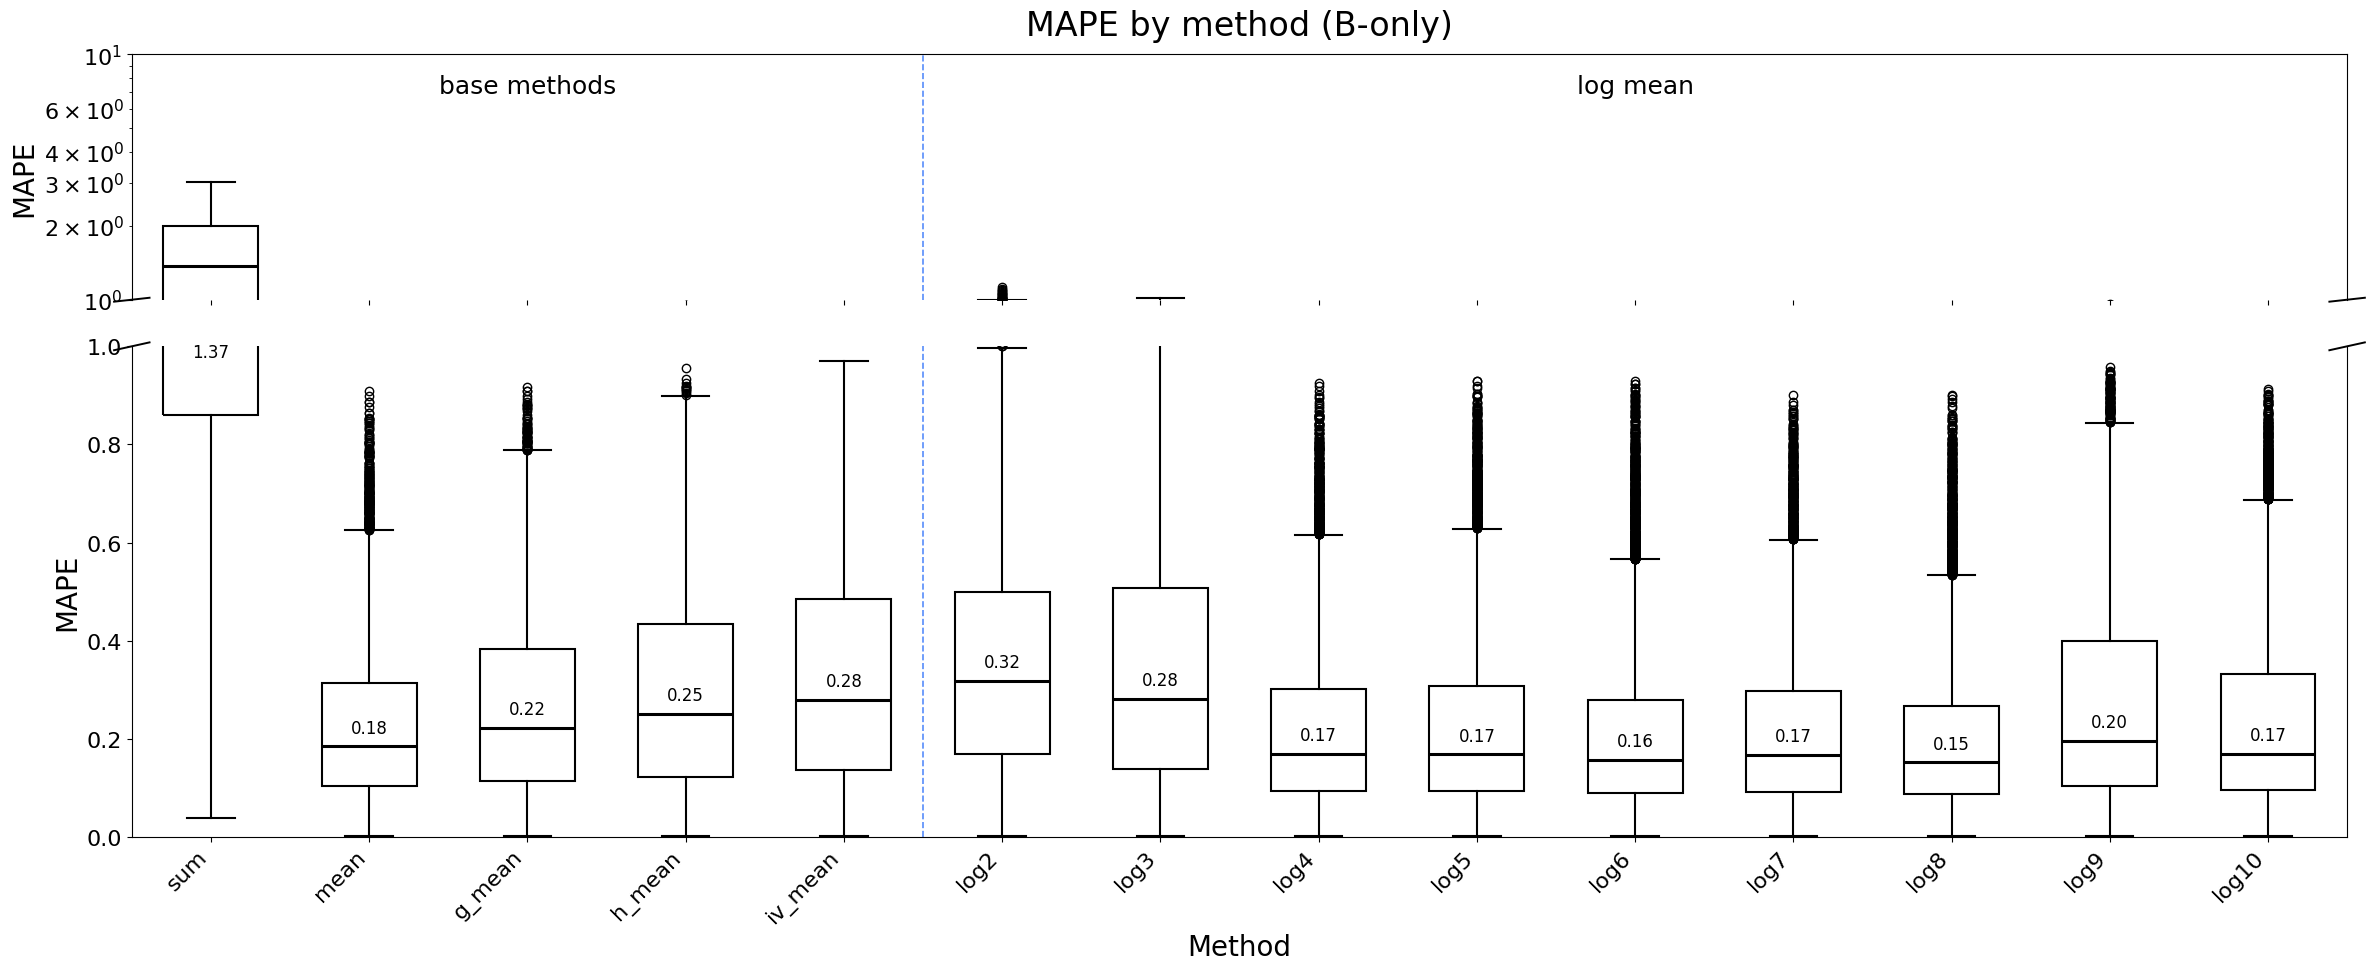

[Figure 1] Best method by mean MAPE: cluster_log8_meansame_sumdiff
[Figure 1] Saved plot: mape_by_method_Bonly_1000_1.png
[Figure 1] Saved summary: mape_summary_Bonly_1000_1.csv


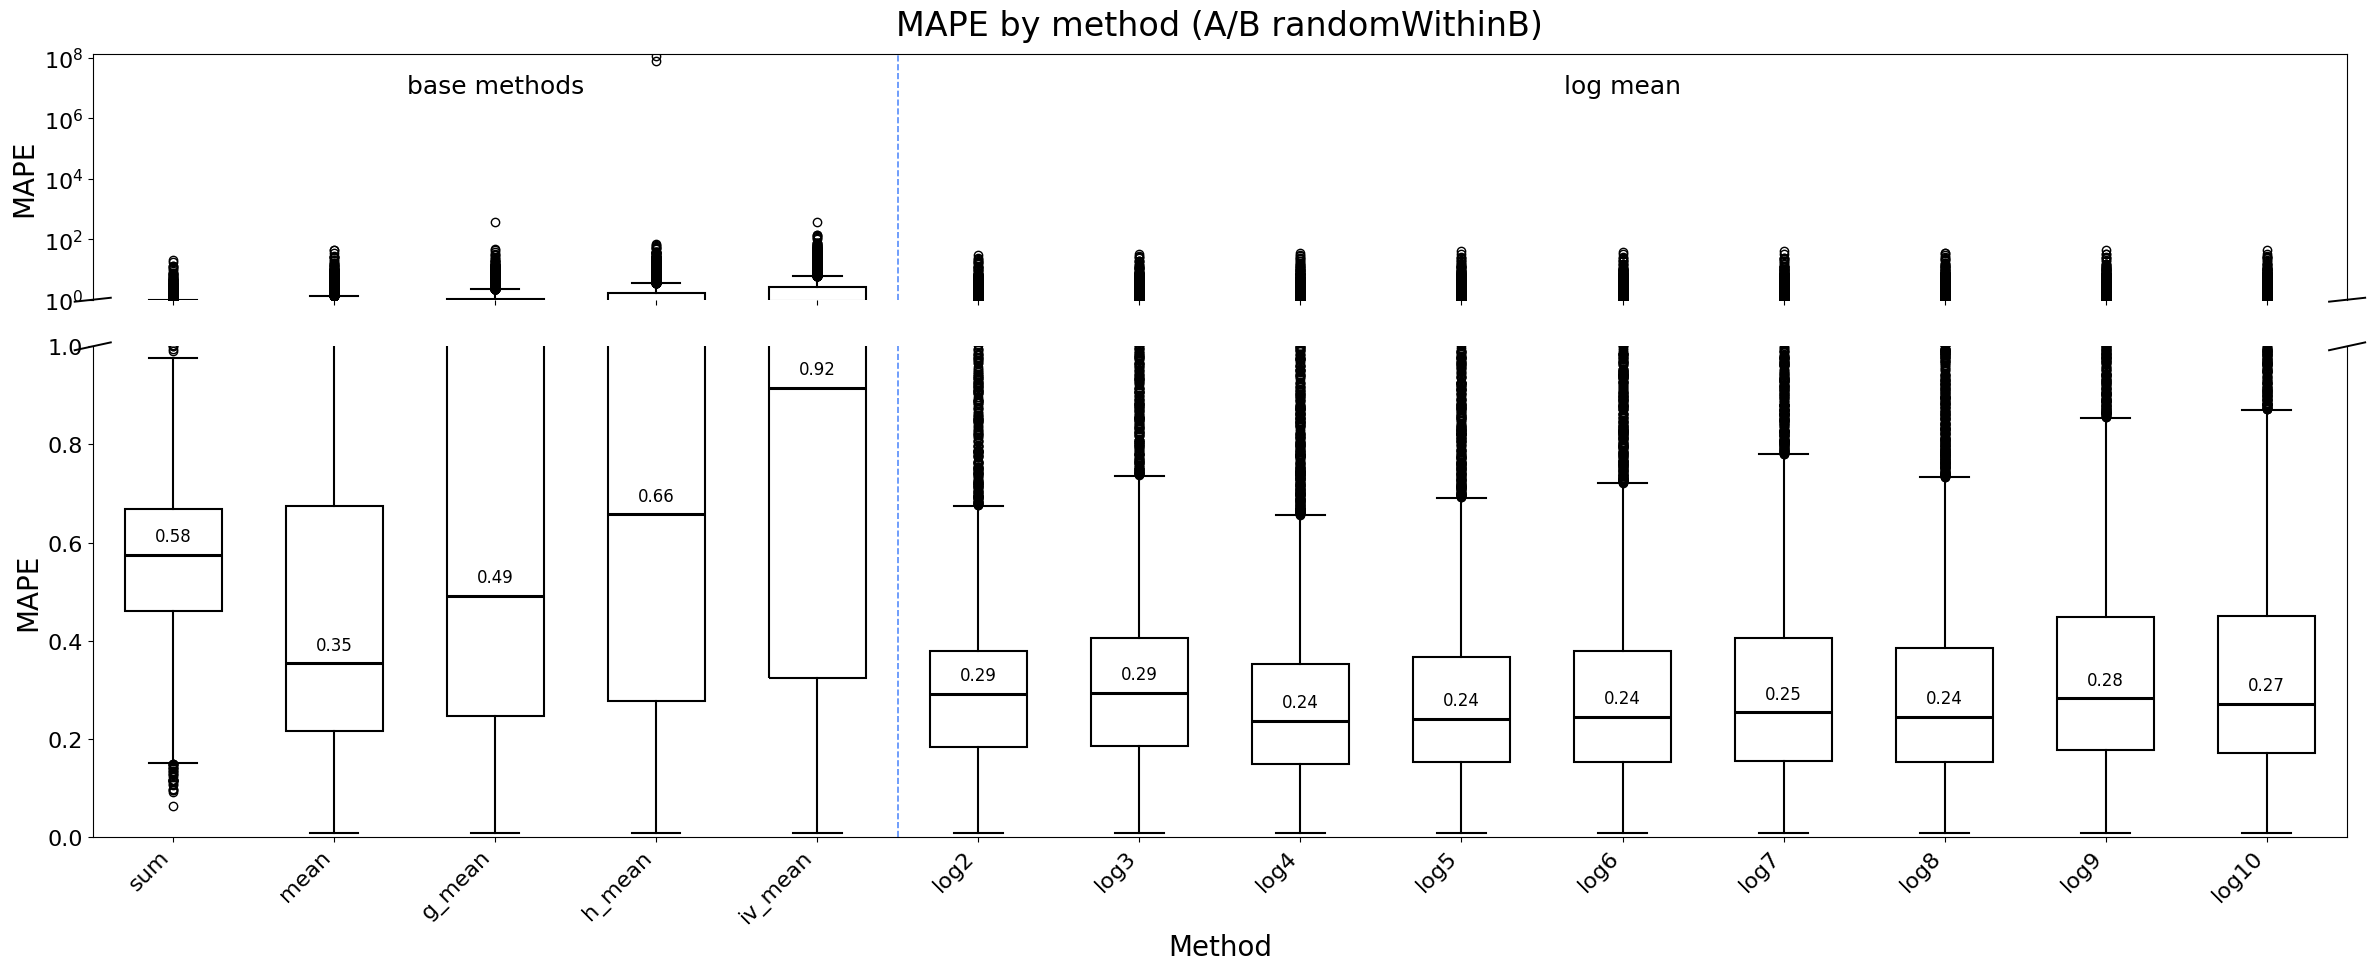

[Figure 2] Best method by mean MAPE: cluster_log2_meansame_sumdiff
[Figure 2] Saved plot: mape_by_method_randomWithinB_1000.png
[Figure 2] Saved summary: mape_summary_randomWithinB_1000.csv


In [13]:

# Plot

TITLE_FS = 24
AXIS_LABEL_FS = 20
TICK_FS = 16
GROUP_LABEL_FS = 18
MEDIAN_TEXT_FS = 12

plt.rcParams.update({
    "font.size": TICK_FS,
    "axes.titlesize": TITLE_FS,
    "axes.labelsize": AXIS_LABEL_FS,
    "xtick.labelsize": TICK_FS,
    "ytick.labelsize": TICK_FS,
    "legend.fontsize": TICK_FS,
})


# read two cs

input_path = Path("repeated_runs_detail_Bonly_1000_1.csv")
input_path_1 = Path("repeated_runs_detail_randomWithinB_1000.csv")

df = pd.read_csv(input_path)
df_1 = pd.read_csv(input_path_1)


# order

method_order = [
    "sum_all",
    "mean_all",
    "geometric_mean_all",
    "harmonic_mean_all",
    "inverse_variance_mean_all",
] + [f"cluster_log{i}_meansame_sumdiff" for i in range(2, 11)]

label_map = {
    "sum_all": "sum",
    "mean_all": "mean",
    "geometric_mean_all": "g_mean",
    "harmonic_mean_all": "h_mean",
    "inverse_variance_mean_all": "iv_mean",
    **{f"cluster_log{i}_meansame_sumdiff": f"log{i}" for i in range(2, 11)},
}


# filtering

plot_df = df[df["method"].isin(method_order)].copy()
plot_df_1 = df_1[df_1["method"].isin(method_order)].copy()


# summary

summary = (
    plot_df.groupby("method", as_index=False)
    .agg(
        mean_MAPE=("MAPE", "mean"),
        median_MAPE=("MAPE", "median"),
        mean_relative_bias=("relative_bias", "mean"),
        median_relative_bias=("relative_bias", "median"),
    )
)
summary["order"] = summary["method"].map({m: i for i, m in enumerate(method_order)})
summary = summary.sort_values("order").drop(columns="order")
summary["label"] = summary["method"].map(label_map)

summary_1 = (
    plot_df_1.groupby("method", as_index=False)
    .agg(
        mean_MAPE=("MAPE", "mean"),
        median_MAPE=("MAPE", "median"),
        mean_relative_bias=("relative_bias", "mean"),
        median_relative_bias=("relative_bias", "median"),
    )
)
summary_1["order"] = summary_1["method"].map({m: i for i, m in enumerate(method_order)})
summary_1 = summary_1.sort_values("order").drop(columns="order")
summary_1["label"] = summary_1["method"].map(label_map)

best_method = summary.loc[summary["mean_MAPE"].idxmin(), "method"]
best_method_1 = summary_1.loc[summary_1["mean_MAPE"].idxmin(), "method"]


# plots

data_MAPE = [plot_df.loc[plot_df["method"] == m, "MAPE"].dropna().values for m in method_order]
data_MAPE_1 = [plot_df_1.loc[plot_df_1["method"] == m, "MAPE"].dropna().values for m in method_order]

labels = [label_map[m] for m in method_order]

medians_MAPE = [np.median(vals) if len(vals) else np.nan for vals in data_MAPE]
medians_MAPE_1 = [np.median(vals) if len(vals) else np.nan for vals in data_MAPE_1]


# two panels

def make_broken_boxplot(plot_df, data_MAPE, medians_MAPE, labels, title, plot_path):
    fig, (ax_top, ax_bottom) = plt.subplots(
        2, 1, figsize=(24, 10), sharex=True, gridspec_kw={"height_ratios": [1, 2]}
    )

    box_kwargs = dict(
        patch_artist=True,
        widths=0.6,
        showfliers=True,
        medianprops=dict(color="black", linewidth=2.2),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        boxprops=dict(linewidth=1.5),
    )

    bp_top = ax_top.boxplot(data_MAPE, **box_kwargs)
    bp_bottom = ax_bottom.boxplot(data_MAPE, **box_kwargs)

    for box in bp_top["boxes"]:
        box.set_facecolor("none")
    for box in bp_bottom["boxes"]:
        box.set_facecolor("none")

    ax_bottom.set_ylim(0, 1)

    all_max = np.nanmax(plot_df["MAPE"].values)
    ax_top.set_yscale("log")
    ax_top.set_ylim(1, max(10, all_max * 1.1))

    # separator between base methods and log methods
    separator_x = 5.5
    ax_bottom.axvline(separator_x, linestyle="--", linewidth=1.2)
    ax_top.axvline(separator_x, linestyle="--", linewidth=1.2)

    ax_top.set_title(title, fontsize=TITLE_FS, pad=14)
    ax_top.set_ylabel("MAPE", fontsize=AXIS_LABEL_FS)
    ax_bottom.set_ylabel("MAPE", fontsize=AXIS_LABEL_FS)
    ax_bottom.set_xlabel("Method", fontsize=AXIS_LABEL_FS)

    ax_bottom.set_xticks(range(1, len(labels) + 1))
    ax_bottom.set_xticklabels(labels, rotation=45, ha="right", fontsize=TICK_FS)

    ax_top.tick_params(axis="y", labelsize=TICK_FS)
    ax_bottom.tick_params(axis="y", labelsize=TICK_FS)

    ax_top.text(
        3, 0.92, "base methods",
        ha="center", va="top",
        transform=ax_top.get_xaxis_transform(),
        fontsize=GROUP_LABEL_FS
    )
    ax_top.text(
        10, 0.92, "log mean",
        ha="center", va="top",
        transform=ax_top.get_xaxis_transform(),
        fontsize=GROUP_LABEL_FS
    )

    for i, med in enumerate(medians_MAPE, start=1):
        if np.isfinite(med):
            y_text = min(med + 0.02, 0.97)
            ax_bottom.text(
                i, y_text, f"{med:.2f}",
                ha="center", va="bottom",
                fontsize=MEDIAN_TEXT_FS, color="black"
            )

    ax_top.spines["bottom"].set_visible(False)
    ax_bottom.spines["top"].set_visible(False)
    ax_top.tick_params(labeltop=False)
    ax_bottom.xaxis.tick_bottom()

    d = 0.008
    kwargs = dict(transform=ax_top.transAxes, color="k", clip_on=False, linewidth=1.4)
    ax_top.plot((-d, +d), (-d, +d), **kwargs)
    ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)

    kwargs.update(transform=ax_bottom.transAxes)
    ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)
    ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

    plt.tight_layout()
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()



# fig1: B_arg vs B_true

plot_path = Path("mape_by_method_Bonly_1000_1.png")
summary_path = Path("mape_summary_Bonly_1000_1.csv")

make_broken_boxplot(
    plot_df=plot_df,
    data_MAPE=data_MAPE,
    medians_MAPE=medians_MAPE,
    labels=labels,
    title="MAPE by method (B-only)",
    plot_path=plot_path,
)

summary.to_csv(summary_path, index=False)

print(f"[Figure 1] Best method by mean MAPE: {best_method}")
print(f"[Figure 1] Saved plot: {plot_path}")
print(f"[Figure 1] Saved summary: {summary_path}")


# fig 2: A/B ratio version

plot_path_1 = Path("mape_by_method_randomWithinB_1000.png")
summary_path_1 = Path("mape_summary_randomWithinB_1000.csv")

make_broken_boxplot(
    plot_df=plot_df_1,
    data_MAPE=data_MAPE_1,
    medians_MAPE=medians_MAPE_1,
    labels=labels,
    title="MAPE by method (A/B randomWithinB)",
    plot_path=plot_path_1,
)

summary_1.to_csv(summary_path_1, index=False)

print(f"[Figure 2] Best method by mean MAPE: {best_method_1}")
print(f"[Figure 2] Saved plot: {plot_path_1}")
print(f"[Figure 2] Saved summary: {summary_path_1}")